In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("/content/Quote-Equity-DLF-EQ-16-03-2025-16-03-2026.csv")

In [6]:
df

,DATE,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
0,16-Mar-2026,EQ,543.00,545.70,524.60,542.75,530.20,530.35,533.02,886.8,524.60,6921559,"3,68,93,44,778.95",70767
1,13-Mar-2026,EQ,557.25,558.90,540.45,558.10,541.75,542.75,547.08,886.8,540.45,5007908,"2,73,97,28,863.40",63229
2,12-Mar-2026,EQ,568.40,571.75,555.55,573.20,557.60,558.10,562.13,886.8,553.55,3176429,"1,78,55,78,539.15",44597
3,11-Mar-2026,EQ,585.30,595.00,571.65,584.55,573.70,573.20,585.03,886.8,553.55,3717062,"2,17,45,76,250.05",58005
4,10-Mar-2026,EQ,580.20,587.00,575.25,574.95,585.30,584.55,581.75,886.8,553.55,4701725,"2,73,52,14,013.85",87706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,21-Mar-2025,EQ,694.90,717.50,694.30,694.30,697.80,695.90,702.88,967.6,622.00,7145524,"5,02,24,31,813.95",86576
244,20-Mar-2025,EQ,698.00,706.50,689.05,697.55,693.00,694.30,696.28,967.6,622.00,4635864,"3,22,78,81,868.00",53006
245,19-Mar-2025,EQ,677.00,698.70,675.80,674.80,696.50,697.55,689.28,967.6,622.00,3398422,"2,34,24,72,512.15",70694
246,18-Mar-2025,EQ,660.50,682.90,660.50,655.55,676.75,674.80,674.47,967.6,622.00,3686355,"2,48,63,46,479.30",69816


In [9]:
df.columns = df.columns.str.strip()
df['DATE']=pd.to_datetime(df['DATE'])
df.sort_values('DATE',inplace=True)
df.set_index('DATE',inplace=True)


In [11]:
df.head()

,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
DATE,,,,,,,,,,,,,
2025-03-17,EQ,661.8,662.3,651.95,658.10,656.20,655.55,657.17,967.6,622.0,1805199,"1,18,63,28,716.05",44168
2025-03-18,EQ,660.5,682.9,660.50,655.55,676.75,674.80,674.47,967.6,622.0,3686355,"2,48,63,46,479.30",69816
2025-03-19,EQ,677.0,698.7,675.80,674.80,696.50,697.55,689.28,967.6,622.0,3398422,"2,34,24,72,512.15",70694
2025-03-20,EQ,698.0,706.5,689.05,697.55,693.00,694.30,696.28,967.6,622.0,4635864,"3,22,78,81,868.00",53006
2025-03-21,EQ,694.9,717.5,694.30,694.30,697.80,695.90,702.88,967.6,622.0,7145524,"5,02,24,31,813.95",86576


In [12]:
if df['CLOSE'].dtype == 'O':
    df['CLOSE'] = df['CLOSE'].astype(str).str.replace(',', '').str.replace('"', '').astype(float)

In [15]:
missing = df['CLOSE'].isna().sum()
df['CLOSE'] = df['CLOSE'].fillna(method='ffill')

In [16]:
df.head()

,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
DATE,,,,,,,,,,,,,
2025-03-17,EQ,661.8,662.3,651.95,658.10,656.20,655.55,657.17,967.6,622.0,1805199,"1,18,63,28,716.05",44168
2025-03-18,EQ,660.5,682.9,660.50,655.55,676.75,674.80,674.47,967.6,622.0,3686355,"2,48,63,46,479.30",69816
2025-03-19,EQ,677.0,698.7,675.80,674.80,696.50,697.55,689.28,967.6,622.0,3398422,"2,34,24,72,512.15",70694
2025-03-20,EQ,698.0,706.5,689.05,697.55,693.00,694.30,696.28,967.6,622.0,4635864,"3,22,78,81,868.00",53006
2025-03-21,EQ,694.9,717.5,694.30,694.30,697.80,695.90,702.88,967.6,622.0,7145524,"5,02,24,31,813.95",86576


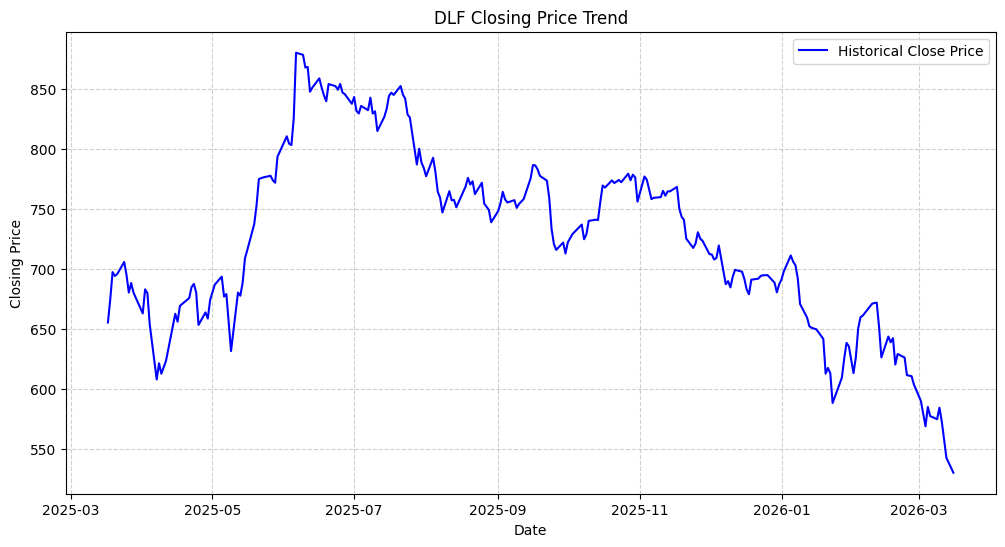

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['CLOSE'], label='Historical Close Price', color='blue')
plt.title('DLF Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

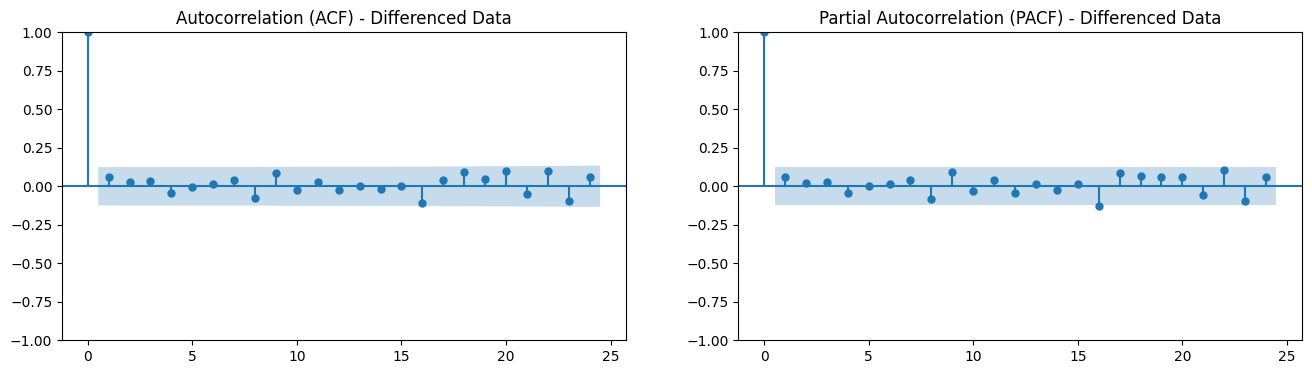

In [26]:
diff_close = df['CLOSE'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(diff_close, ax=axes[0], title="Autocorrelation (ACF) - Differenced Data")
plot_pacf(diff_close, ax=axes[1], method='ywm', title="Partial Autocorrelation (PACF) - Differenced Data")
plt.show()

In [27]:
model = ARIMA(df['CLOSE'], order=(1, 1, 1))
fitted_model = model.fit()

In [28]:
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  CLOSE   No. Observations:                  248
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -980.716
Date:                Tue, 17 Mar 2026   AIC                           1967.433
Time:                        07:08:00   BIC                           1977.961
Sample:                             0   HQIC                          1971.671
                                - 248                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4454      0.954      0.467      0.641      -1.425       2.315
ma.L1         -0.3849      0.982     -0.392      0.695      -2.311       1.541
sigma2       164.5378     10.952     15.024      0.0

In [29]:
forecast_steps = 30
forecast = fitted_model.forecast(steps=forecast_steps)

In [30]:
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='B')
forecast.index = forecast_index

In [31]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

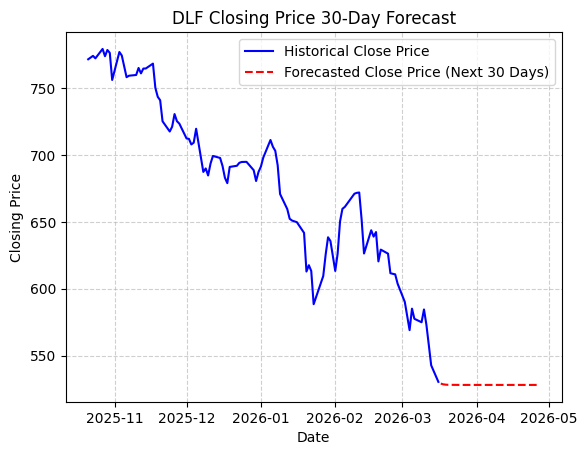

In [32]:
plt.plot(df.index[-100:], df['CLOSE'].iloc[-100:], label='Historical Close Price', color='blue')
plt.plot(forecast.index, forecast, label='Forecasted Close Price (Next 30 Days)', color='red', linestyle='dashed')

plt.title('DLF Closing Price 30-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Conclusion** : Strictly based on this historical price data and the ARIMA statistical model, you should expect the stock to stabilize and hover around the 528–530 range in the near term, rather than exhibiting a strong upward or downward trend.